In [51]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import networkx as nx
from torch_geometric.utils import to_networkx

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader

from torch import nn
from torch_geometric.nn.models.dimenet import DimeNetPlusPlus, triplets, radius_graph
from torch_scatter import scatter
from torch_geometric.nn import MessagePassing

In [52]:
# Configuration and Hyperparameters
SEED = 50
MIN_NODES = 10  
MAX_NODES = 10 
DATA_ROOT = os.environ.get("QM9_ROOT", "~/TPNN/QM9/dataset")
# SAVE_DIR = 'mincut_viz'

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# os.makedirs(SAVE_DIR, exist_ok=True)


BATCH_SIZE = 1
# Load and Preprocess Data
dataset = QM9(root=DATA_ROOT)

# Filter dataset for graphs with > MIN_NODES nodes
filtered_data = [d for d in dataset if d.num_nodes <= MAX_NODES and d.num_nodes >= MIN_NODES]
print(f"Total QM9 molecules: {len(dataset)}")
print(f"Filtered dataset size (< {MAX_NODES} nodes and > {MIN_NODES} nodes): {len(filtered_data)}")

# Split Data
n = len(filtered_data)
train_size = int(0.4 * n)
val_size = int(0.1 * n)
test_size = n - train_size - val_size

train_dataset = filtered_data[:train_size]
val_dataset = filtered_data[train_size:train_size+val_size]
test_dataset = filtered_data[train_size+val_size:]

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train/Val/Test sizes: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}")



Total QM9 molecules: 130831
Filtered dataset size (< 10 nodes and > 10 nodes): 483
Train/Val/Test sizes: 193/48/242


In [53]:
class DimeNetPlusPlusNode(DimeNetPlusPlus):
    """DimeNet++ wrapper that returns per-node embeddings (hidden_channels dim)
    instead of graph-level scalar predictions.

    Pretrained loading (requires TensorFlow):
        model, (train, val, test) = DimeNetPlusPlusNode.from_qm9_pretrained(root, dataset, target)
        # This works because the inherited @classmethod uses cls(...) internally.

    TF-free loading from a saved state dict:
        model = DimeNetPlusPlusNode.from_state_dict(path, **kwargs)
    """

    def forward(self, z, pos, batch=None):
        """
        Forward pass returning node embeddings after all interaction blocks.

        Args:
            z (Tensor): Atomic number of each atom [num_atoms].
            pos (Tensor): Coordinates of each atom [num_atoms, 3].
            batch (LongTensor, optional): Batch vector [num_atoms].

        Returns:
            Tensor: Node embeddings [num_atoms, hidden_channels].
        """
        edge_index = radius_graph(pos, r=self.cutoff, batch=batch,
                                  max_num_neighbors=self.max_num_neighbors)

        i, j, idx_i, idx_j, idx_k, idx_kj, idx_ji = triplets(
            edge_index, num_nodes=z.size(0))

        dist = (pos[i] - pos[j]).pow(2).sum(dim=-1).sqrt()

        # Calculate angles (DimeNet++ formulation)
        pos_jk, pos_ij = pos[idx_j] - pos[idx_k], pos[idx_i] - pos[idx_j]
        a = (pos_ij * pos_jk).sum(dim=-1)
        b = torch.cross(pos_ij, pos_jk, dim=1).norm(dim=-1)
        angle = torch.atan2(b, a)

        rbf = self.rbf(dist)
        sbf = self.sbf(dist, angle, idx_kj)

        # Embedding block — produces edge-level features [E, hidden_channels]
        x = self.emb(z, rbf, i, j)

        # Interaction blocks — x stays edge-level [E, hidden_channels]
        for interaction_block in self.interaction_blocks:
            x = interaction_block(x, rbf, sbf, idx_kj, idx_ji)

        # Scatter edge features to nodes: [E, hidden] -> [N, hidden]
        node_embeddings = scatter(x, i, dim=0, dim_size=pos.size(0), reduce='mean')

        return node_embeddings  # [num_atoms, hidden_channels]

    @classmethod
    def from_state_dict(cls, state_dict_path, **kwargs):
        """Load from a saved PyTorch state dict (no TensorFlow needed).

        Example:
            # First, save a pretrained model's weights:
            #   torch.save(pretrained_model.state_dict(), 'dimenet_pp.pt')
            # Then load into a node-embedding variant:
            #   model = DimeNetPlusPlusNode.from_state_dict('dimenet_pp.pt',
            #       hidden_channels=128, out_channels=1, num_blocks=4,
            #       int_emb_size=64, basis_emb_size=8, out_emb_channels=256,
            #       num_spherical=7, num_radial=6)
        """
        model = cls(**kwargs)
        state_dict = torch.load(state_dict_path, map_location='cpu', weights_only=True)
        model.load_state_dict(state_dict, strict=False)
        return model

In [59]:
class ScalarKernel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1):
        super(ScalarKernel, self).__init__()
        self.kernel = torch.nn.Sequential(
            torch.nn.Linear(in_channels, hidden_channels),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_channels, out_channels),
            torch.nn.Sigmoid()
        )

    def forward(self, x, edge_index):
        
        node_scalars = self.kernel(x)
        src, dst = edge_index
        
        # Gather values for source and destination nodes
        src_values = node_scalars[src]
        dst_values = node_scalars[dst]
        
        # The edge value is the maximum of its endpoints
        edge_scalars = torch.maximum(src_values, dst_values)
        
        return node_scalars, edge_scalars

def build_hierarchical_graph(node_features, edge_index, batch, node_values, edge_values, grouping_param=0.000):
    """
    Constructs a hierarchical graph structure based on edge values.
    
    Args:
        node_features (Tensor): [N, F]
        edge_index (Tensor): [2, E]
        batch (Tensor): [N]
        node_values (Tensor): [N, 1]
        edge_values (Tensor): [E, 1] OR [E]
        grouping_param (float): Grouping threshold parameter.
    
    Returns:
        combined_features (Tensor): [N_total, F]
        combined_edge_index (Tensor): [2, E_total]
        node_level_ids (Tensor): [N_total]
        edge_level_ids (Tensor): [E_total]
    """
    device = node_features.device
    num_nodes = node_features.shape[0]
    num_features = node_features.shape[1]
    
    # Flatten edge_values if needed
    if edge_values.dim() > 1:
        edge_values = edge_values.squeeze()

    # --- 1. Edge Sorting ---
    sorted_idx = torch.argsort(edge_values)
    sorted_values = edge_values[sorted_idx]
    sorted_u = edge_index[0, sorted_idx]
    sorted_v = edge_index[1, sorted_idx]

    # --- 2. Initialization ---
    all_features = [node_features]
    all_edges_list = [] # Will hold tuples of (src, dst) for inter-layer
    all_level_ids = [torch.zeros(num_nodes, dtype=torch.long, device=device)]
    all_edge_level_ids = []
    
    # Maintains mapping from Original Node ID -> Current Cluster ID
    # Initially, each node is its own cluster (0..N-1)
    # The 'Current Cluster ID' corresponds to the node index in the current top layer.
    global_cluster_map = torch.arange(num_nodes, device=device)
    current_num_clusters = num_nodes
    
    current_level = 0
    
    # Determine number of graphs (assuming batch is 0..B-1)
    num_graphs = batch.max().item() + 1
    
    while current_num_clusters > num_graphs:
        
        # --- 3. Identify Candidates ---
        # Map sorted edges to current cluster IDs
        c_u = global_cluster_map[sorted_u]
        c_v = global_cluster_map[sorted_v]
        
        # Filter: Only edges connecting DIFFERENT clusters are valid
        diff_mask = c_u != c_v
        
        if not diff_mask.any():
            break # No more merges possible (e.g., graphs fully connected internally)
            
        # Get active edges
        valid_indices = torch.nonzero(diff_mask).squeeze()
        if valid_indices.dim() == 0:
            valid_indices = valid_indices.unsqueeze(0)
            
        # The lowest value edge connecting different clusters
        first_valid_idx = valid_indices[0]
        min_cluster_diff_val = sorted_values[first_valid_idx]
        
        # Define Threshold
        threshold = min_cluster_diff_val + grouping_param
        
        # Slice the candidate window
        limit_idx = torch.searchsorted(sorted_values, threshold, right=True)
        
        # Filter active edges within the threshold
        cand_indices_mask = valid_indices < limit_idx
        merging_indices = valid_indices[cand_indices_mask]
        
        if merging_indices.numel() == 0:
            break
            
        # Get the clusters that need to merge
        merge_u = c_u[merging_indices]
        merge_v = c_v[merging_indices]
        
        # --- 4. Compute Connected Components (Next Layer) ---
        new_parent_map = torch.arange(current_num_clusters, device=device)
        
        # Iterative Min-Propagate for CC
        for _ in range(20):
            p_u = new_parent_map[merge_u]
            p_v = new_parent_map[merge_v]
            min_p = torch.minimum(p_u, p_v)
            
            try:
                # Optimized scatter reduce for PyTorch 1.12+
                new_parent_map.scatter_reduce_(0, merge_u, min_p, reduce='amin', include_self=True)
                new_parent_map.scatter_reduce_(0, merge_v, min_p, reduce='amin', include_self=True)
            except AttributeError:
                # Fallback loops
                safe_mask_u = new_parent_map[merge_u] > min_p
                if safe_mask_u.any():
                    new_parent_map[merge_u[safe_mask_u]] = min_p[safe_mask_u]
                
                safe_mask_v = new_parent_map[merge_v] > min_p
                if safe_mask_v.any():
                    new_parent_map[merge_v[safe_mask_v]] = min_p[safe_mask_v]

        # Compact the IDs to 0..K-1
        unique_parents, inverse_indices = torch.unique(new_parent_map, return_inverse=True)
        num_new_clusters = unique_parents.size(0)
        
        # --- 5. Build Next Layer ---
        
        # Features: Initialize with Zeros
        new_layer_features = torch.zeros((num_new_clusters, num_features), device=device)
        all_features.append(new_layer_features)
        
        # Level IDs for Nodes
        current_level += 1
        all_level_ids.append(torch.full((num_new_clusters,), current_level, dtype=torch.long, device=device))
        
        # Inter-Level Edges (Bidirectional)
        src_nodes = torch.arange(current_num_clusters, device=device)
        dst_nodes = inverse_indices
        
        all_edges_list.append((src_nodes, dst_nodes))
        
        # Level IDs for Edges (Using lower level index, so level 0 means L0-L1 edge)
        # 2 directions per edge -> 2 * src_nodes.size(0)
        edge_level = current_level - 1
        all_edge_level_ids.append(
            torch.full((src_nodes.size(0) * 2,), edge_level, dtype=torch.long, device=device)
        )
        
        # Update State
        global_cluster_map = inverse_indices[global_cluster_map]
        current_num_clusters = num_new_clusters
        
        if current_num_clusters <= num_graphs:
            break

    # --- 6. Assemble Final Graph ---
    
    # Calculate Node Offsets
    layer_sizes = [f.shape[0] for f in all_features]
    cumulative_sizes = torch.tensor([0] + layer_sizes[:-1], device=device).cumsum(0)
    
    # Concatenate Features
    combined_features = torch.cat(all_features, dim=0)
    node_level_ids = torch.cat(all_level_ids, dim=0)
    
    # Construct Edge Index
    final_edge_sources = []
    final_edge_targets = []
    
    for i, (src_local, dst_local) in enumerate(all_edges_list):
        offset_src = cumulative_sizes[i]
        offset_dst = cumulative_sizes[i+1]
        
        u = src_local + offset_src
        v = dst_local + offset_dst
        
        final_edge_sources.append(u)
        final_edge_targets.append(v)
        final_edge_sources.append(v) # Bidirectional
        final_edge_targets.append(u)
        
    if len(final_edge_sources) > 0:
        combined_edge_index = torch.stack([
            torch.cat(final_edge_sources),
            torch.cat(final_edge_targets)
        ], dim=0)
        edge_level_ids = torch.cat(all_edge_level_ids, dim=0)
    else:
        combined_edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
        edge_level_ids = torch.empty((0,), dtype=torch.long, device=device)
    
    return combined_features, combined_edge_index, node_level_ids, edge_level_ids


class AgnosticUpwardModule(MessagePassing):
    def __init__(self, feature_dim):
        # Using 'add' aggregation as the divergence operator
        super(AgnosticUpwardModule, self).__init__(aggr='mean') 
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, feature_dim)
        )

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_i, x_j):
        # x_j are the daughter nodes (source), x_i is the parent node (target)
        tmp = torch.cat([x_i, x_j], dim=1)
        return self.mlp(tmp)

class AgnosticDownwardModule(MessagePassing):
    def __init__(self, feature_dim):
        # Permutation invariant aggregation down the hierarchy
        super(AgnosticDownwardModule, self).__init__(aggr='mean')
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, feature_dim)
        )

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_i, x_j):
        # x_j is the parent node (source), x_i are the daughter nodes (target)
        tmp = torch.cat([x_i, x_j], dim=1)
        return self.mlp(tmp)

class HierarchicalNetwork(nn.Module):
    def __init__(self, feature_dim):
        super(HierarchicalNetwork, self).__init__()
        # Shared modules across all levels
        self.upward_gnn = AgnosticUpwardModule(feature_dim)
        self.downward_gnn = AgnosticDownwardModule(feature_dim)

    def forward(self, x, edge_index, node_level_id, edge_level_id):
        """
        x: [N, D] (assuming D is feature dimension, batched nodes)
        edge_index: [2, E]
        node_level_id: [N]
        edge_level_id: [E] (optional: can be used if edges have specific features to filter)
        """
        max_level = node_level_id.max().item()
        out_x = x.clone()

        # 1. UPWARD PASS (Bottom-to-Top)
        for l in range(max_level):
            # Find nodes at current level l and next level l+1
            source_mask = (node_level_id[edge_index[0]] == l)
            target_mask = (node_level_id[edge_index[1]] == l + 1)
            
            # Filter for edges going UP: from l to l+1
            up_edge_mask = source_mask & target_mask
            up_edge_index = edge_index[:, up_edge_mask]
            
            # Only update if there are edges connecting these levels
            if up_edge_index.size(1) > 0:
                # Calculate updates
                updated_features = self.upward_gnn(out_x, up_edge_index)
                
                # Apply updates ONLY to the target nodes at level l+1
                # (Since PyTorch Geometric updates all nodes in the graph based on the 
                # edge index, we selectively overwrite only the target nodes)
                target_nodes = up_edge_index[1].unique()
                out_x[target_nodes] = updated_features[target_nodes]

        # 2. DOWNWARD PASS (Top-to-Bottom)
        for l in range(max_level, 0, -1):
            # Find nodes at current level l and lower level l-1
            source_mask = (node_level_id[edge_index[0]] == l)
            target_mask = (node_level_id[edge_index[1]] == l - 1)
            
            # Filter for edges going DOWN: from l to l-1
            down_edge_mask = source_mask & target_mask
            down_edge_index = edge_index[:, down_edge_mask]
            
            if down_edge_index.size(1) > 0:
                updated_features = self.downward_gnn(out_x, down_edge_index)
                
                # Apply updates ONLY to the target nodes at level l-1
                target_nodes = down_edge_index[1].unique()
                out_x[target_nodes] = updated_features[target_nodes]

        return out_x
    
class Regressor(nn.Module):
    def __init__(self, feature_dim, output_dim=1):
        super(Regressor, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.mlp(x)
# =========================================================================
# Discrete Subgraph Generation (Non-diff) (only for visualization/analysis)
# =========================================================================

def generate_filtration_subgraphs(data, node_values, edge_values):
    """
    Constructs the actual NetworkX graphs for the filtration sequence.
    This part is for analysis/visualization and is not differentiable.
    """
    # 1. Collect all unique critical values (thresholds)
    # We combine node and edge values and sort them unique
    all_values = torch.cat([node_values, edge_values])
    thresholds, _ = torch.sort(torch.unique(all_values))
    
    filtration_sequence = []
    
    # We use a NetworkX graph for easy subgraph handling
    G_full = to_networkx(data, to_undirected=True)
    
    print(f"Generating {len(thresholds)} filtration steps...")
    
    for t in thresholds:
        # Identify nodes and edges that exist at time t
        # (Using <= allows the complex to grow)
        valid_nodes_mask = (node_values <= t).detach().cpu().numpy()
        valid_edges_mask = (edge_values <= t).detach().cpu().numpy()
        
        # Get indices
        valid_node_indices = torch.where(node_values <= t)[0].tolist()
        
        # Create subgraph
        # Note: In a strict simplex filtration, we add nodes/edges one by one.
        # Here we add "batches" of elements that share the exact same scalar value.
        subg = nx.Graph()
        
        # Add only valid nodes
        for node_idx in valid_node_indices:
            subg.add_node(node_idx, pos=G_full.nodes[node_idx].get('pos', None))
            
        # Add only valid edges
        # We iterate original edge_index to find valid ones
        # (Converting edge_index to list of pairs for iteration)
        edges_np = data.edge_index.t().cpu().numpy()
        for i, (u, v) in enumerate(edges_np):
            if valid_edges_mask[i]:
                # Only add edge if BOTH endpoints are already in subgraph
                # (The max condition technically guarantees this, but safety check)
                if subg.has_node(u) and subg.has_node(v):
                    subg.add_edge(u, v)
        
        filtration_sequence.append((t.item(), subg))
        
    return filtration_sequence
    

In [55]:
class TPNN(torch.nn.Module):
    def __init__(self, hidden_channels, output_channels=1,
                 pretrained_root=None, pretrained_dataset=None, pretrained_target=None,
                 freeze_encoder=False):
        super().__init__()
        
        # 1. Base Encoder: DimeNet++
        if pretrained_root is not None and pretrained_dataset is not None and pretrained_target is not None:
            # Load pretrained encoder from QM9
            self.encoder, _ = DimeNetPlusPlusNode.from_qm9_pretrained(
                pretrained_root, pretrained_dataset, pretrained_target
            )
            # Pretrained uses hidden_channels=128
            hidden_channels = 128
            print(f"Loaded pretrained DimeNet++ encoder (target={pretrained_target})")
            
            if freeze_encoder:
                for param in self.encoder.parameters():
                    param.requires_grad = False
                print("Encoder weights frozen")
        else:
            # Train from scratch
            self.encoder = DimeNetPlusPlusNode(
                hidden_channels=hidden_channels,
                out_channels=1,  # out_channels unused in our forward (node embeddings)
                num_blocks=3,
                int_emb_size=64,
                basis_emb_size=8,
                out_emb_channels=256,
                num_spherical=7,
                num_radial=6,
                cutoff=5.0,
                max_num_neighbors=32,
                envelope_exponent=5,
                num_before_skip=1,
                num_after_skip=2,
                num_output_layers=3,
                output_initializer='glorot_orthogonal',
            )
            
        self.kernel = ScalarKernel(in_channels=hidden_channels, hidden_channels=hidden_channels, out_channels=output_channels)
        
        self.HierMP = HierarchicalNetwork(feature_dim=hidden_channels)
        
        self.regressor = Regressor(feature_dim=hidden_channels, output_dim=output_channels)
    
    def forward(self, batch):
        
 
        x = self.encoder(batch.z, batch.pos, batch.batch)  # Get node embeddings from DimeNet++
        
        node_values, edge_values = self.kernel(x, batch.edge_index)  # Apply kernel to node embeddings
        
        combined_features, combined_edge_index, node_level_ids, edge_level_ids = build_hierarchical_graph(
            x, batch.edge_index, batch.batch, node_values, edge_values, grouping_param=0.000
        )   
        x_post = self.HierMP(combined_features, combined_edge_index, node_level_ids, edge_level_ids)
        last_node_index = torch.argmax(node_level_ids).item()
        last_node_features = x_post[last_node_index,:]
        output = self.regressor(last_node_features)
        
        return x, x_post, node_values, edge_values, output  # Return node embeddings without global pooling
    

Loaded pretrained DimeNet++ encoder (target=7)
Encoder weights frozen
Testing pipeline with batch of size: 1
Batch node feature shape: torch.Size([10])
Batch position shape: torch.Size([10, 3])
Batch edge index shape: torch.Size([2, 20])
Batch batch vector shape: torch.Size([10])
Batch num nodes: 10
Node embeddings shape: torch.Size([10, 128])
Node scalar values shape: torch.Size([10, 1])
Edge scalar values shape: torch.Size([20, 1])
Post-Hierarchical node features shape: torch.Size([35, 128])
Output shape: torch.Size([1])
Combined node features shape: torch.Size([35, 128])
Combined edge index shape: torch.Size([2, 68])
Node level IDs shape: torch.Size([35])
Edge level IDs shape: torch.Size([68])
Unique node levels: tensor([0, 1, 2, 3, 4, 5], device='cuda:0')
Unique edge levels: tensor([0, 1, 2, 3, 4], device='cuda:0')
Generating 10 filtration steps...


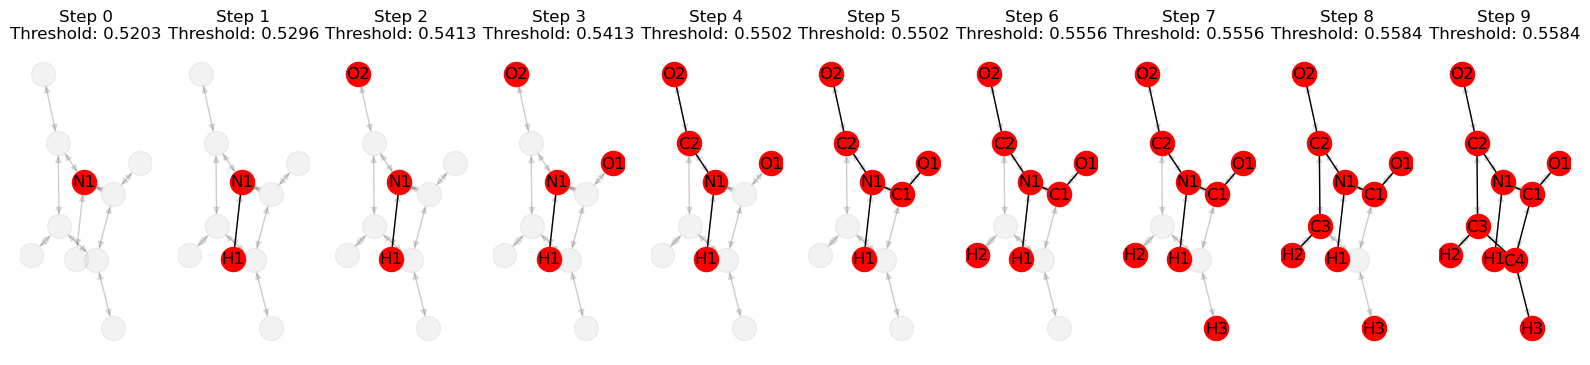

In [56]:
# --- Option A: Load pretrained DimeNet++ from QM9 ---
# target: 0=mu, 1=alpha, 2=HOMO, 3=LUMO, 5=R2, 6=ZPVE, 7=U0, 8=U, 9=H, 10=G, 11=Cv
# (target=4 is not available for pretrained models)
PRETRAINED_TARGET = 7
PRETRAINED_ROOT = os.path.expanduser("~/TPNN/dimenetpp-qm9")
ATOM_MAP_VIZ = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 16: 'S', 17: 'Cl'}

def test_pipeline(batch, tpnn_model):
    
    print("Testing pipeline with batch of size:", batch.num_graphs)
    print("Batch node feature shape:", batch.z.shape)
    print("Batch position shape:", batch.pos.shape)
    print("Batch edge index shape:", batch.edge_index.shape)
    print("Batch batch vector shape:", batch.batch.shape)
    print("Batch num nodes:", batch.num_nodes)
    
    tpnn_model.eval()
    with torch.no_grad():
        x, x_post,node_values, edge_values, output= tpnn_model(batch)
    
    print("Node embeddings shape:", x.shape)
    print("Node scalar values shape:", node_values.shape)
    print("Edge scalar values shape:", edge_values.shape)
    print("Post-Hierarchical node features shape:", x_post.shape)
    print("Output shape:", output.shape)

    
    return x, x_post, node_values, edge_values, output

batch = next(iter(train_loader))
batch = batch.to(device)
x, x_post, node_values, edge_values, output= test_pipeline(batch, TPNN(hidden_channels=128, pretrained_root=PRETRAINED_ROOT, pretrained_dataset=dataset, pretrained_target=PRETRAINED_TARGET, freeze_encoder=True).to(device))

combined_node_features, combined_edge_index, node_ids, edge_ids = build_hierarchical_graph(x, batch.edge_index, batch.batch, node_values, edge_values)
print("Combined node features shape:", combined_node_features.shape)
print("Combined edge index shape:", combined_edge_index.shape)  
print("Node level IDs shape:", node_ids.shape)
print("Edge level IDs shape:", edge_ids.shape)
print("Unique node levels:", torch.unique(node_ids))
print("Unique edge levels:", torch.unique(edge_ids))

# Build atom labels for this batch
z_np = batch.z.cpu().numpy()
_atom_counts = {}
unique_labels_viz = {}
for i in range(len(z_np)):
    sym = ATOM_MAP_VIZ.get(z_np[i], str(z_np[i]))
    _atom_counts[sym] = _atom_counts.get(sym, 0) + 1
    unique_labels_viz[i] = f"{sym}{_atom_counts[sym]}"

subgraphs = generate_filtration_subgraphs(batch, node_values, edge_values)

# E. Visualize All steps
steps_to_plot = [i for i in range(len(subgraphs))]
fig, axes = plt.subplots(1, len(steps_to_plot), figsize=(len(steps_to_plot)*2, 4))
pos = nx.spring_layout(to_networkx(batch), seed=42) # Fixed layout for consistency

for i, step_idx in enumerate(steps_to_plot):
    thresh, G = subgraphs[step_idx]
    ax = axes[i]
    
    # Draw the full "background" graph faintly
    nx.draw(to_networkx(batch), pos, ax=ax, alpha=0.1, node_color='grey')
    
    # Draw the active filtration subgraph with atom labels
    if len(G.nodes) > 0:
        sub_labels = {n: unique_labels_viz.get(n, str(n)) for n in G.nodes()}
        nx.draw(G, pos, ax=ax, with_labels=True, labels=sub_labels,
                node_color='red', edge_color='black')
    
    ax.set_title(f"Step {step_idx}\nThreshold: {thresh:.4f}")

plt.show()

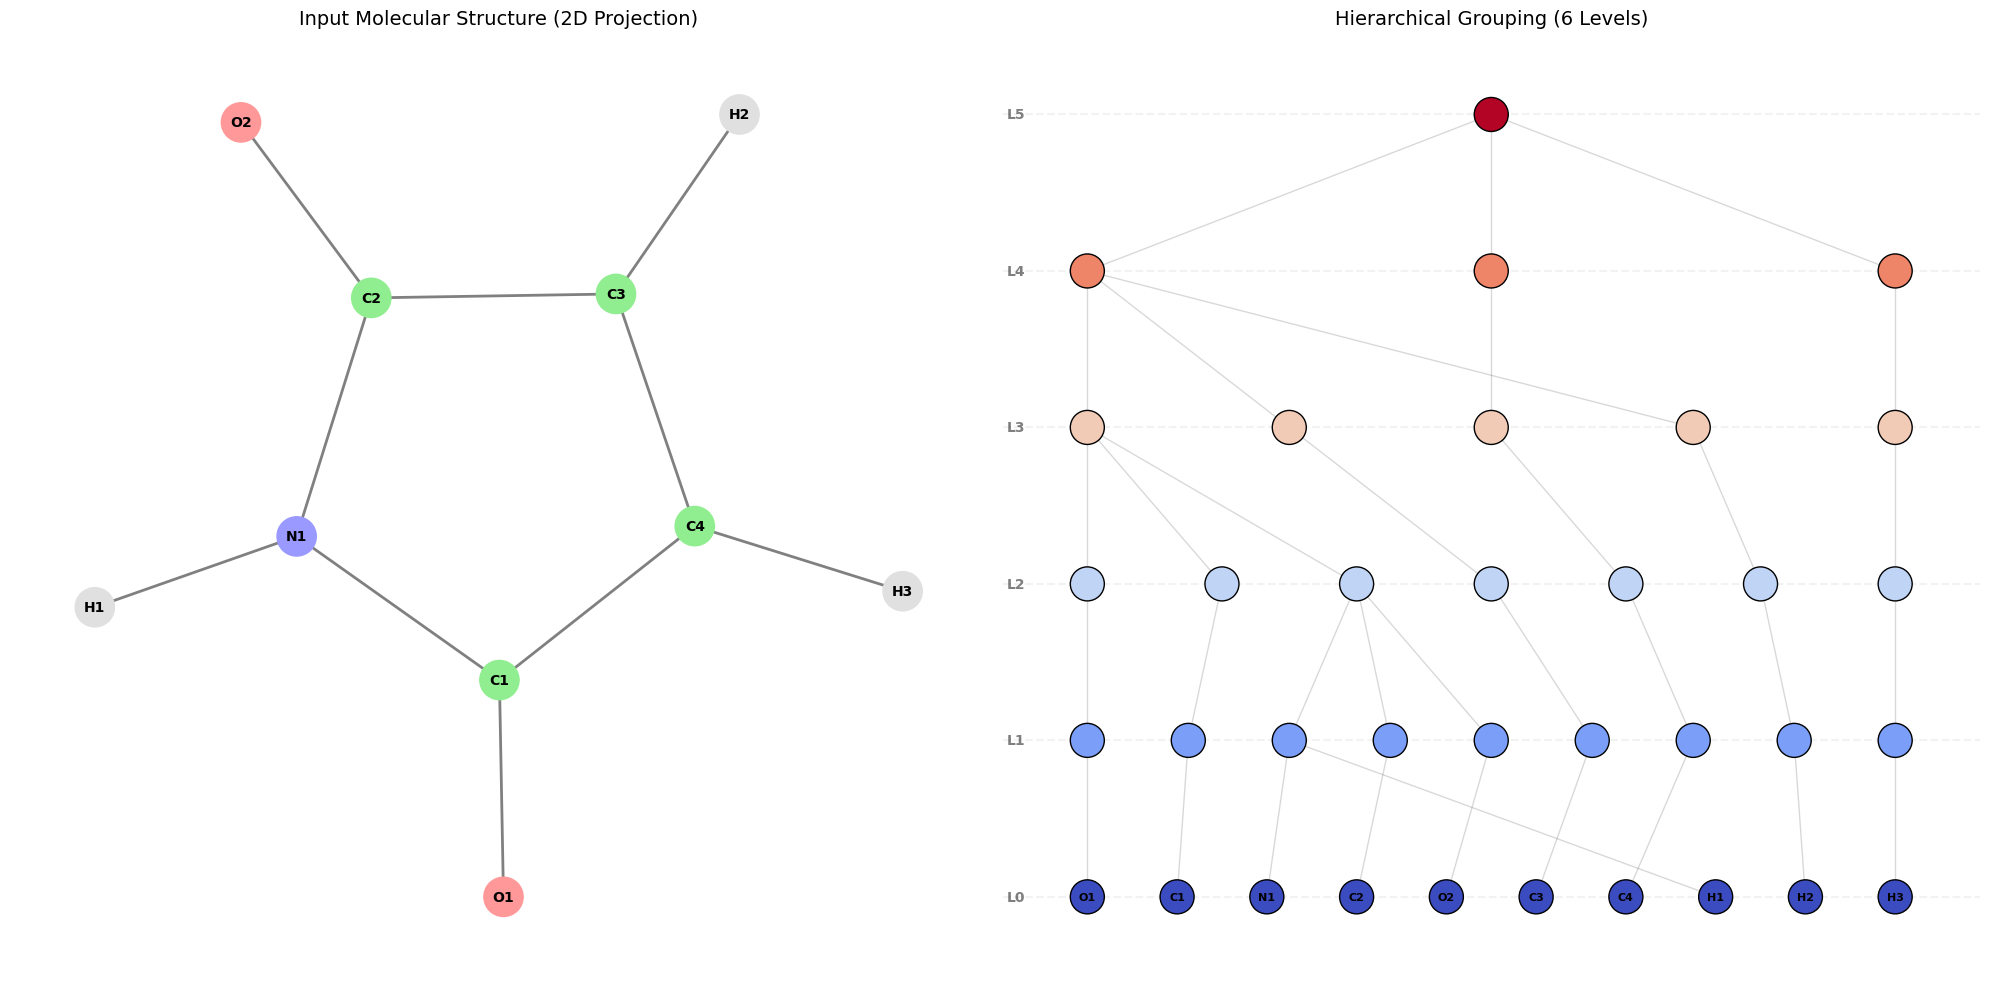

In [57]:
def visualize_hierarchy(batch, combined_edge_index, node_level_ids):
    """
    Visualizes the molecular structure alongside the constructed hierarchical graph.
    
    Args:
        batch: PyG batch object containing the molecule (pos, z, edge_index).
        combined_edge_index (Tensor): Edges of the full hierarchy.
        node_level_ids (Tensor): Level assignment for each node in hierarchy.
    """
    # Atom Dictionary
    ATOM_MAP = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 16: 'S', 17: 'Cl'}
    
    # Convert to numpy/cpu
    z = batch.z.cpu().numpy()
    pos = batch.pos.cpu().numpy()
    levels = node_level_ids.cpu().numpy()
    edges = combined_edge_index.cpu().numpy().T
    
    # Generate Unique Labels (e.g., C1, C2, H1, H2...)
    atom_counts = {}
    unique_labels = {}
    for i in range(len(z)):
        atom_type = z[i]
        symbol = ATOM_MAP.get(atom_type, str(atom_type))
        if symbol not in atom_counts:
            atom_counts[symbol] = 0
        atom_counts[symbol] += 1
        unique_labels[i] = f"{symbol}{atom_counts[symbol]}"
    
    # Setup Figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # -----------------------------
    # Left Plot: Molecular Structure
    # -----------------------------
    ax_mol = axes[0]
    G_mol = to_networkx(batch, to_undirected=True)
    
    # Layout: use spring_layout seeded from 2D projection to avoid overlapping atoms
    pos_init = {i: pos[i, :2] for i in range(len(G_mol))}
    pos_mol = nx.spring_layout(G_mol, pos=pos_init, seed=42, k=2.0/np.sqrt(len(z)), iterations=100)
    
    colors = ['#FF9999' if z[i]==8 else '#9999FF' if z[i]==7 else '#90EE90' if z[i]==6 else '#E0E0E0' for i in range(len(z))]
    
    nx.draw(G_mol, pos_mol, ax=ax_mol, with_labels=True, labels=unique_labels, 
            node_color=colors, node_size=800, edge_color='gray', width=2, font_size=10, font_weight='bold')
    ax_mol.set_title("Input Molecular Structure (2D Projection)", fontsize=14)
    ax_mol.axis('off')

    # -----------------------------
    # Right Plot: Hierarchy
    # -----------------------------
    ax_hier = axes[1]
    G_hier = nx.Graph()
    G_hier.add_edges_from(edges)
    
    # Filter nodes - ensure all nodes are in graph
    G_hier.add_nodes_from(range(len(levels)))

    # --- Compute Layout ---
    # Strategy: Place nodes at each level equally spaced.
    
    pos_hier = {}
    
    # Group nodes by level
    nodes_by_level = {}
    for i, l in enumerate(levels):
        if l not in nodes_by_level: nodes_by_level[l] = []
        nodes_by_level[l].append(i)
        
    sorted_levels = sorted(nodes_by_level.keys())
    
    # Equal spacing for ALL levels
    for l in sorted_levels:
        level_nodes = sorted(nodes_by_level[l])
        n_nodes = len(level_nodes)
        for idx, node_id in enumerate(level_nodes):
            norm_x = (idx / max(1, n_nodes - 1)) * 10 if n_nodes > 1 else 5.0
            pos_hier[node_id] = (norm_x, float(l))

    # --- Draw Hierarchy ---
    
    # Node Colors by Level (cmap)
    node_colors = [levels[n] for n in G_hier.nodes()]
    
    # Node Labels: Only for Level 0
    hier_labels = {}
    for n in G_hier.nodes():
        if levels[n] == 0:
            if n < len(z):
                hier_labels[n] = unique_labels.get(n, '?')
            else:
                hier_labels[n] = '?'
        else:
            hier_labels[n] = '' 
            
    # Draw edges first
    nx.draw_networkx_edges(G_hier, pos_hier, ax=ax_hier, alpha=0.3, edge_color='gray')
    
    # Draw nodes
    nx.draw_networkx_nodes(G_hier, pos_hier, ax=ax_hier, 
                                node_color=node_colors, cmap=plt.cm.coolwarm, 
                                node_size=600, edgecolors='black')
    
    # Draw labels (font size slightly smaller for indexed labels)
    nx.draw_networkx_labels(G_hier, pos_hier, ax=ax_hier, labels=hier_labels, font_size=8, font_weight='bold')
    
    # Add level lines (horizontal grid)
    max_level = levels.max()
    for l in range(max_level + 1):
        ax_hier.axhline(y=l, color='gray', linestyle='--', alpha=0.1, zorder=-1)
        ax_hier.text( -1, l, f"L{l}", verticalalignment='center', fontweight='bold', alpha=0.5)

    ax_hier.set_title(f"Hierarchical Grouping ({max_level+1} Levels)", fontsize=14)
    ax_hier.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run Visualization on the previously computed result
visualize_hierarchy(batch, combined_edge_index, node_ids)

In [ ]:

import os
import shutil
import glob
import contextlib
import io
import imageio.v2 as imageio
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for saving
import matplotlib.pyplot as plt

# ===================== Configuration =====================
TARGET_IDX = 11      
PRETRAINED_TARGET = TARGET_IDX
PRETRAINED_ROOT = os.path.expanduser("~/TPNN/dimenetpp-qm9")
EPOCHS = 50
LR = 1e-4
VIZ_DIR = "training_viz_v2"
ATOM_MAP = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 16: 'S', 17: 'Cl'}

# Clear / create viz folder
if os.path.exists(VIZ_DIR):
    shutil.rmtree(VIZ_DIR)
os.makedirs(VIZ_DIR, exist_ok=True)

# ===================== Target Normalization (z-score from training set) =====================
class TargetNormalizer:
    """Z-score normalizer fitted on training data only."""
    def __init__(self, train_dataset, target_idx):
        targets = torch.tensor([d.y[0, target_idx].item() for d in train_dataset])
        self.mean = targets.mean().item()
        self.std = targets.std().item()
        # Guard against zero std (constant target)
        if self.std < 1e-12:
            self.std = 1.0
        print(f"TargetNormalizer | target={target_idx} | mean={self.mean:.6f} | std={self.std:.6f}")

    def normalize(self, y):
        """Transform raw target to z-score."""
        return (y - self.mean) / self.std

    def inverse(self, y_norm):
        """Transform z-score back to original scale."""
        return y_norm * self.std + self.mean

# normalizer = TargetNormalizer(train_dataset, TARGET_IDX)

# ===================== Visualization Helper =====================
def save_epoch_viz(batch, node_values, edge_values, combined_edge_index,
                   node_level_ids, epoch, train_loss, val_loss, save_dir):
    """Save hierarchy + filtration visualization for a single graph to disk."""
    z = batch.z.cpu().numpy()
    pos_3d = batch.pos.cpu().numpy()
    levels = node_level_ids.cpu().numpy()
    edges = combined_edge_index.cpu().numpy().T

    # Atom labels
    atom_counts = {}
    unique_labels = {}
    for i in range(len(z)):
        symbol = ATOM_MAP.get(z[i], str(z[i]))
        atom_counts[symbol] = atom_counts.get(symbol, 0) + 1
        unique_labels[i] = f"{symbol}{atom_counts[symbol]}"

    # Filtration subgraphs (suppress prints)
    with contextlib.redirect_stdout(io.StringIO()):
        subgraphs = generate_filtration_subgraphs(batch, node_values, edge_values)
    n_steps = len(subgraphs)

    # Pick evenly-spaced filtration steps for bottom row
    n_filt_cols = min(n_steps, 8)
    step_indices = np.linspace(0, n_steps - 1, n_filt_cols, dtype=int) if n_steps > 0 else []
    n_filt_cols = max(n_filt_cols, 1)  # at least 1 col so subplot grid is valid

    fig = plt.figure(figsize=(max(20, n_filt_cols * 3), 14))
    fig.suptitle(f"Epoch {epoch} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}",
                 fontsize=16, fontweight='bold')

    # ---- Top Left: Molecular Structure ----
    ax_mol = fig.add_subplot(2, 2, 1)
    G_mol = to_networkx(batch, to_undirected=True)
    # Use spring_layout seeded from 2D projection to avoid overlapping atoms
    pos_init = {i: pos_3d[i, :2] for i in range(len(z))}
    pos_mol = nx.spring_layout(G_mol, pos=pos_init, seed=42, k=2.0/np.sqrt(len(z)), iterations=100)
    colors_mol = [
        '#FF9999' if z[i] == 8 else
        '#9999FF' if z[i] == 7 else
        '#90EE90' if z[i] == 6 else '#E0E0E0'
        for i in range(len(z))
    ]
    nx.draw(G_mol, pos_mol, ax=ax_mol, with_labels=True, labels=unique_labels,
            node_color=colors_mol, node_size=800, edge_color='gray', width=2,
            font_size=10, font_weight='bold')
    ax_mol.set_title("Molecular Structure", fontsize=12)
    ax_mol.axis('off')

    # ---- Top Right: Hierarchy ----
    ax_hier = fig.add_subplot(2, 2, 2)
    G_hier = nx.Graph()
    G_hier.add_edges_from(edges)
    G_hier.add_nodes_from(range(len(levels)))

    # Layout: equally space all nodes at each level
    pos_hier = {}
    nodes_by_level = {}
    for i, l in enumerate(levels):
        nodes_by_level.setdefault(l, []).append(i)

    for l in sorted(nodes_by_level.keys()):
        level_nodes = sorted(nodes_by_level[l])
        n_nodes = len(level_nodes)
        for idx, nid in enumerate(level_nodes):
            norm_x = (idx / max(1, n_nodes - 1)) * 10 if n_nodes > 1 else 5.0
            pos_hier[nid] = (norm_x, float(l))

    node_colors_hier = [levels[n] for n in G_hier.nodes()]
    hier_labels = {n: (unique_labels.get(n, '') if levels[n] == 0 else '') for n in G_hier.nodes()}

    nx.draw_networkx_edges(G_hier, pos_hier, ax=ax_hier, alpha=0.3, edge_color='gray')
    nx.draw_networkx_nodes(G_hier, pos_hier, ax=ax_hier, node_color=node_colors_hier,
                           cmap=plt.cm.coolwarm, node_size=600, edgecolors='black')
    nx.draw_networkx_labels(G_hier, pos_hier, ax=ax_hier, labels=hier_labels,
                            font_size=8, font_weight='bold')

    max_level = int(levels.max())
    for l in range(max_level + 1):
        ax_hier.axhline(y=l, color='gray', linestyle='--', alpha=0.1, zorder=-1)
        ax_hier.text(-1, l, f"L{l}", verticalalignment='center', fontweight='bold', alpha=0.5)

    ax_hier.set_title(f"Hierarchy ({max_level + 1} Levels)", fontsize=12)
    ax_hier.axis('off')

    # ---- Bottom Row: Filtration Steps ----
    if len(step_indices) > 0:
        # Use the same spring layout as the molecular structure for consistency
        pos_spring = nx.spring_layout(G_mol, pos=pos_init, seed=42, k=2.0/np.sqrt(len(z)), iterations=100)
        for col, si in enumerate(step_indices):
            ax = fig.add_subplot(2, n_filt_cols, n_filt_cols + col + 1)
            thresh, G_sub = subgraphs[si]
            nx.draw(G_mol, pos_spring, ax=ax, alpha=0.1, node_color='grey', node_size=100)
            if len(G_sub.nodes) > 0:
                # Use unique_labels so filtration nodes match molecular graph labels
                sub_labels = {n: unique_labels.get(n, str(n)) for n in G_sub.nodes()}
                nx.draw(G_sub, pos_spring, ax=ax, with_labels=True, labels=sub_labels,
                        node_color='red', edge_color='black', node_size=200, font_size=6)
            ax.set_title(f"t={thresh:.3f}", fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"epoch_{epoch:03d}.png"), dpi=100, bbox_inches='tight')
    plt.close(fig)


# ===================== Model Setup =====================
model = TPNN(
    hidden_channels=128,
    output_channels=1,
    pretrained_root=PRETRAINED_ROOT,
    pretrained_dataset=dataset,
    pretrained_target=PRETRAINED_TARGET,
    freeze_encoder=True
).to(device)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
criterion = nn.MSELoss()

# Grab the first training batch for per-epoch visualization
viz_batch = next(iter(train_loader)).to(device)

# ===================== Training Loop =====================
print(f"Training TPNN | Target: {TARGET_IDX} | Epochs: {EPOCHS} | LR: {LR}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("-" * 60)

train_losses = []
val_losses = []
val_maes = []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for batch_data in train_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()

        x, x_post, nv, ev, pred = model(batch_data)
        # Normalize target to z-score space for loss computation
        target_raw = batch_data.y[:, TARGET_IDX]
        # target_norm = normalizer.normalize(target_raw)

        loss = criterion(pred.view_as(target_raw), target_raw)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    val_loss_total = 0.0
    val_mae_total = 0.0
    val_n_samples = 0
    val_batches = 0
    with torch.no_grad():
        for vb in val_loader:
            vb = vb.to(device)
            _, _, _, _, vpred = model(vb)
            vtarget_raw = vb.y[:, TARGET_IDX]
            # vtarget_norm = normalizer.normalize(vtarget_raw)

            # MSE in normalized space (for loss curve consistency)
            val_loss_total += criterion(vpred.view_as(vtarget_raw), vtarget_raw).item()
            val_batches += 1

            # MAE in original scale
            # vpred_original = normalizer.inverse(vpred.view_as(vtarget_raw))
            val_mae_total += (vpred - vtarget_raw).abs().sum().item()
            val_n_samples += vtarget_raw.numel()

    avg_val_loss = val_loss_total / max(val_batches, 1)
    avg_val_mae = val_mae_total / max(val_n_samples, 1)
    val_losses.append(avg_val_loss)
    val_maes.append(avg_val_mae)

    # --- Visualization (first training graph, every epoch) ---
    with torch.no_grad():
        x_viz, x_post_viz, nv_viz, ev_viz, out_viz = model(viz_batch)
        cf, cei, nli, eli = build_hierarchical_graph(
            x_viz, viz_batch.edge_index, viz_batch.batch, nv_viz, ev_viz
        )
        save_epoch_viz(viz_batch, nv_viz, ev_viz, cei, nli,
                       epoch, avg_train_loss, avg_val_loss, VIZ_DIR)

    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Val MAE: {avg_val_mae:.6f}")

print("-" * 60)
print("Training complete!")

# ===================== Create GIF =====================
image_files = sorted(glob.glob(os.path.join(VIZ_DIR, "epoch_*.png")))
if image_files:
    images = [imageio.imread(f) for f in image_files]
    gif_path = os.path.join(VIZ_DIR, "training_evolution.gif")
    imageio.mimsave(gif_path, images, duration=0.5)
    print(f"GIF saved: {gif_path} ({len(images)} frames)")
else:
    print("No images found to create GIF.")

# ===================== Plot Loss Curves =====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(train_losses, label='Train Loss (norm)')
ax1.plot(val_losses, label='Val Loss (norm)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss (z-score space)')
ax1.set_title('Training Progress (Normalized)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_maes, label='Val MAE (original scale)', color='tab:orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE (original units)')
ax2.set_title('Validation MAE (Original Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "loss_curves.png"), dpi=100)
plt.show()


Loaded pretrained DimeNet++ encoder (target=11)
Encoder weights frozen
Training TPNN | Target: 11 | Epochs: 50 | LR: 0.0001
Train: 193 | Val: 48 | Test: 242
------------------------------------------------------------
Epoch 000 | Train Loss: 214.230954 | Val Loss: 81.166470 | Val MAE: 7.813489
Epoch 001 | Train Loss: 26.163120 | Val Loss: 29.208134 | Val MAE: 4.229354
Epoch 002 | Train Loss: 9.954416 | Val Loss: 16.833984 | Val MAE: 3.075905
Epoch 003 | Train Loss: 5.803264 | Val Loss: 13.878209 | Val MAE: 2.754202
Epoch 004 | Train Loss: 5.334801 | Val Loss: 21.766618 | Val MAE: 3.763342
Epoch 005 | Train Loss: 4.888845 | Val Loss: 14.717567 | Val MAE: 2.935032
Epoch 006 | Train Loss: 4.532405 | Val Loss: 11.676802 | Val MAE: 2.598252
Epoch 007 | Train Loss: 4.759173 | Val Loss: 21.234964 | Val MAE: 3.675130
Epoch 008 | Train Loss: 4.328093 | Val Loss: 13.444236 | Val MAE: 2.809929
Epoch 009 | Train Loss: 4.490231 | Val Loss: 11.894156 | Val MAE: 2.643654
Epoch 010 | Train Loss: 4.880

: 

In [ ]:
import os
import glob
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from torch_geometric.nn import radius_graph

# 1. Define the Net Class
class TPNN(nn.Module):
    def __init__(self, hidden_channels=128, out_channels=1):
        super().__init__()
        
        # 1. Base Encoder: DimeNet++
        self.encoder = DimeNetPlusPlusNode(
            hidden_channels=hidden_channels,
            out_channels=hidden_channels,
            num_blocks=4,
            int_emb_size=64,
            basis_emb_size=8,
            out_emb_channels=256,
            num_spherical=7,
            num_radial=6,
            cutoff=5.0,
            max_num_neighbors=32,
            envelope_exponent=5,
            num_before_skip=1,
            num_after_skip=2,
            num_output_layers=3,
            output_initializer='glorot_orthogonal', # Fix for zero embeddings
        )
        
        # 2. Scalar Kernel
        self.scalar_kernel = ScalarKernel(hidden_channels)
        
        # 3. Hierarchy Message Passing
        self.hiermp = HierMP(hidden_channels, hidden_channels)
        
        # 4. Regression Head
        self.regressor = RegressionHead(hidden_channels, out_channels)
        
    def forward(self, batch):
        # A. Get Node Embeddings
        # Note: DimeNet++ expects (z, pos, batch)
        node_embeddings = self.encoder(batch.z, batch.pos, batch.batch)
        
        # B. Get Node Scalars
        # Recompute connectivity for scalar kernel/hierarchy building
        # (radius graph with r=5.0 matches DimeNet default cutoff)
        edge_index = batch.edge_index
        if edge_index is None:
            edge_index = radius_graph(batch.pos, r=5.0, batch=batch.batch, max_num_neighbors=32)
        
        node_scalars = self.scalar_kernel(node_embeddings, edge_index)
        
        # C. Build Hierarchy
        hierarchy_data = build_hierarchy(node_embeddings, node_scalars, edge_index, batch.batch)
        
        # D. Hierarchical Message Passing
        # 'out' contains embeddings for the whole hierarchy
        out_features = self.hiermp(hierarchy_data)
        
        # E. Regression
        # Only uses the top-most nodes for prediction
        pred = self.regressor(out_features, hierarchy_data['layer_sizes'])
        
        return pred, hierarchy_data

# 2. Define Visualization Saver
def save_hierarchy_viz(hierarchy_data, batch_data_obj, epoch, save_dir, batch_idx_in_batch=0):
    """
    Visualizes and saves the hierarchy for a single graph.
    """
    # Move to CPU for plotting
    batch_vector = hierarchy_data['batch'].detach().cpu()
    edge_index = hierarchy_data['edge_index'].detach().cpu()
    
    mask = batch_vector == batch_idx_in_batch
    node_indices = torch.arange(batch_vector.size(0))[mask]
    
    mapping = {global_idx.item(): local_idx for local_idx, global_idx in enumerate(node_indices)}
    
    src, dst = edge_index
    edge_mask = torch.isin(src, node_indices) & torch.isin(dst, node_indices)
    valid_src = src[edge_mask]
    valid_dst = dst[edge_mask]
    
    G = nx.DiGraph()
    
    # Layers logic
    layer_sizes = hierarchy_data['layer_sizes']
    layer_ranges = []
    curr = 0
    for size in layer_sizes:
        layer_ranges.append((curr, curr + size))
        curr += size
        
    def get_layer(global_idx):
        for li, (start, end) in enumerate(layer_ranges):
            if start <= global_idx < end:
                return li
        return -1
    
    # Cutoff logic
    nodes_per_layer_in_graph = []
    for (start, end) in layer_ranges:
        count = ((node_indices >= start) & (node_indices < end)).sum().item()
        nodes_per_layer_in_graph.append(count)
        
    cutoff_layer = len(layer_sizes) 
    for i, count in enumerate(nodes_per_layer_in_graph):
        if count == 1:
            cutoff_layer = i
            break
            
    # Atom Types
    b_cpu = batch_data_obj.batch.cpu()
    z_cpu = batch_data_obj.z.cpu()
    pos_cpu = batch_data_obj.pos.cpu()
    mol_mask = (b_cpu == batch_idx_in_batch)
    z = z_cpu[mol_mask]
    pos = pos_cpu[mol_mask]
    graph_atom_global_indices = torch.where(mol_mask)[0]
    start_idx = graph_atom_global_indices.min().item() if len(graph_atom_global_indices) > 0 else 0
    atom_types_map = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 16: 'S', 17: 'Cl'}
    
    # Build Graph
    for idx in node_indices:
        idx_item = idx.item()
        layer = get_layer(idx_item)
        label = str(idx_item)
        
        if layer == 0:
            if idx_item < layer_sizes[0]:
                atom_offset = idx_item - start_idx
                if 0 <= atom_offset < len(z):
                    atomic_num = z[atom_offset].item()
                    sym = atom_types_map.get(atomic_num, str(atomic_num))
                    label = f"{sym}_{atom_offset}"
        
        if layer <= cutoff_layer:
            G.add_node(mapping[idx_item], layer=layer, global_id=idx_item, label=label)
            
    for s, d in zip(valid_src, valid_dst):
        s_item, d_item = s.item(), d.item()
        if mapping[s_item] in G.nodes and mapping[d_item] in G.nodes:
            G.add_edge(mapping[s_item], mapping[d_item])
            
    # Figure
    fig = plt.figure(figsize=(20, 8))
    
    # Subplot 1: Hierarchy
    plt.subplot(1, 2, 1)
    if G.number_of_nodes() > 0:
        pos_hier = nx.multipartite_layout(G, subset_key="layer")
        colors = [G.nodes[n]['layer'] for n in G.nodes()]
        labels = nx.get_node_attributes(G, 'label')
        nx.draw_networkx_nodes(G, pos_hier, node_color=colors, cmap=plt.cm.Blues, node_size=500)
        nx.draw_networkx_edges(G, pos_hier, arrowstyle='->', arrowsize=15)
        nx.draw_networkx_labels(G, pos_hier, labels=labels, font_size=8)
        plt.title(f"Hierarchy (Depth {max(colors) if colors else 0})")
        plt.axis('off')
    
    # Subplot 2: Molecule
    plt.subplot(1, 2, 2)
    G_mol = nx.Graph()
    # Nodes
    for i, zi in enumerate(z):
        sym = atom_types_map.get(zi.item(), '?')
        G_mol.add_node(i, symbol=sym)
    
    # Edges
    if hasattr(batch_data_obj, 'edge_index') and batch_data_obj.edge_index is not None:
        ei_cpu = batch_data_obj.edge_index.cpu()
        min_idx = graph_atom_global_indices.min().item()
        max_idx = graph_atom_global_indices.max().item()
        e_mask = (ei_cpu[0] >= min_idx) & (ei_cpu[0] <= max_idx) & (ei_cpu[1] >= min_idx) & (ei_cpu[1] <= max_idx)
        relevant_edges = ei_cpu[:, e_mask]
        for k in range(relevant_edges.size(1)):
            u = relevant_edges[0, k].item() - min_idx
            v = relevant_edges[1, k].item() - min_idx
            if u != v:
                G_mol.add_edge(u, v)

    # Colors derived from L1
    atom_to_l1 = {}
    for n in G.nodes():
        if G.nodes[n]['layer'] == 0:
            parents = [succ for succ in G.successors(n) if G.nodes[succ]['layer'] == 1]
            if parents:
                atom_to_l1[n] = parents[0]
                
    l1_clusters = sorted(list(set(atom_to_l1.values())))
    import matplotlib.colors as mcolors
    palette = list(mcolors.TABLEAU_COLORS.values())
    cluster_color_map = {node: palette[i % len(palette)] for i, node in enumerate(l1_clusters)}
    
    node_colors = []
    labels_mol = {}
    for i in range(len(z)):
        gid = start_idx + i
        if gid in mapping and mapping[gid] in G.nodes:
            n_g = mapping[gid]
            c = cluster_color_map.get(atom_to_l1.get(n_g), 'lightgray')
        else:
            c = 'lightgray'
        node_colors.append(c)
        labels_mol[i] = G_mol.nodes[i]['symbol'] + f"_{i}"
        
    pos_2d = pos.numpy()[:, :2]
    pos_dict = {i: pos_2d[i] for i in range(len(pos_2d))}
    
    nx.draw_networkx_nodes(G_mol, pos_dict, node_color=node_colors, node_size=600, edgecolors='black')
    nx.draw_networkx_edges(G_mol, pos_dict, width=2)
    nx.draw_networkx_labels(G_mol, pos_dict, labels=labels_mol, font_weight='bold')
    plt.title(f"Molecule Epoch {epoch}")
    plt.axis('off')
    
    plt.savefig(f"{save_dir}/epoch_{epoch:03d}.png")
    plt.close(fig)

# 3. Setup and Loops
def train_loop():
    # Settings
    TARGET_IDX = 0 # e.g., U0 (Internal Energy) or GAP
    EPOCHS = 20 # Small number for demonstration
    LEARNING_RATE = 1e-4
    VIZ_DIR = "training_viz"
    os.makedirs(VIZ_DIR, exist_ok=True)
    
    # Initialize
    model = TPNN(hidden_channels=128, out_channels=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()
    
    # Val batch for visualization
    val_batch = next(iter(val_loader)).to(device) 
    
    # Training
    print("Starting Training...")
    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            # Forward
            pred, _ = model(batch)
            
            # Target (Pick one property)
            target = batch.y[:, TARGET_IDX].squeeze(-1)
            
            # Loss
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        
        # Validation & Visualization
        model.eval()
        with torch.no_grad():
            # Validate on fixed batch
            v_pred, v_hier_data = model(val_batch)
            v_target = val_batch.y[:, TARGET_IDX].squeeze(-1)
            v_loss = criterion(v_pred, v_target).item()
            
            # Save Viz (Epoch 0, 1, ...)
            try:
                save_hierarchy_viz(v_hier_data, val_batch, epoch, VIZ_DIR, batch_idx_in_batch=0)
            except Exception as e:
                print(f"Viz Error Epoch {epoch}: {e}")
        
        print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {v_loss:.4f}")
            
    print("Training Complete.")
    
    # Create GIF
    images = []
    sorted_files = sorted(glob.glob(f"{VIZ_DIR}/epoch_*.png"))
    for filename in sorted_files:
        images.append(imageio.imread(filename))
    
    if len(images) > 0:
        gif_path = f"{VIZ_DIR}/training_evolution.gif"
        imageio.mimsave(gif_path, images, duration=0.5) # 0.5s per frame
        print(f"GIF saved at {gif_path}")
    else:
        print("No images found to create GIF.")

# Execute
train_loop()